# Risk and Return

Risk and return are the foundation of portfolio analysis. Investors care not only about expected return, but also about uncertainty, drawdowns, correlations, and the reward received for bearing risk.

Abbreviations used in this notebook:

- **SD**: Standard Deviation.
- **VaR**: Value at Risk.
- **CAGR**: Compound Annual Growth Rate.
- **RF**: Risk-Free Rate.

## 1. Intuition

Return measures reward. Risk measures uncertainty around that reward. A portfolio can reduce risk when assets do not move perfectly together, which is why correlation is central to diversification.

Key risk and return concepts:

- **Expected return**: average return investors expect over a period.
- **Volatility**: standard deviation of returns.
- **Variance**: squared volatility.
- **Covariance**: how two assets move together in return units.
- **Correlation**: standardized co-movement between -1 and +1.
- **Sharpe ratio**: excess return per unit of volatility.
- **Drawdown**: decline from a previous portfolio peak.

## 2. Mathematics

**Expected return:**

$$
E[R] = \sum_i p_i R_i
$$

**Variance:**

$$
\sigma^2 = \frac{1}{n - 1}\sum_{t=1}^{n}(R_t - \bar{R})^2
$$

**Volatility:**

$$
\sigma = \sqrt{\sigma^2}
$$

**Correlation:**

$$
\rho_{A,B} = \frac{Cov(R_A, R_B)}{\sigma_A \sigma_B}
$$

**Two-asset portfolio variance:**

$$
\sigma_p^2 = w_A^2\sigma_A^2 + w_B^2\sigma_B^2 + 2w_Aw_B\rho_{A,B}\sigma_A\sigma_B
$$

**Sharpe ratio:**

$$
\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}
$$


## 3. Implementation

We will simulate two assets, calculate returns, volatility, correlation, and a simple portfolio Sharpe ratio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format
np.random.seed(42)

In [2]:
days = 252
asset_a = np.random.normal(0.0004, 0.012, days)
asset_b = 0.35 * asset_a + np.random.normal(0.00025, 0.009, days)

returns = pd.DataFrame({
    "asset_a": asset_a,
    "asset_b": asset_b,
})

weights = np.array([0.60, 0.40])
portfolio_returns = returns @ weights
risk_free_rate = 0.02

summary = pd.DataFrame({
    "metric": [
        "Asset A annual return",
        "Asset B annual return",
        "Asset A annual volatility",
        "Asset B annual volatility",
        "Correlation",
        "Portfolio annual return",
        "Portfolio annual volatility",
        "Portfolio Sharpe ratio",
    ],
    "value": [
        f"{returns['asset_a'].mean() * 252:.2%}",
        f"{returns['asset_b'].mean() * 252:.2%}",
        f"{returns['asset_a'].std() * np.sqrt(252):.2%}",
        f"{returns['asset_b'].std() * np.sqrt(252):.2%}",
        f"{returns.corr().iloc[0, 1]:.2f}",
        f"{portfolio_returns.mean() * 252:.2%}",
        f"{portfolio_returns.std() * np.sqrt(252):.2%}",
        f"{((portfolio_returns.mean() * 252) - risk_free_rate) / (portfolio_returns.std() * np.sqrt(252)):.2f}",
    ],
})

summary

,metric,value
0,Asset A annual return,8.94%
1,Asset B annual return,15.16%
2,Asset A annual volatility,18.42%
3,Asset B annual volatility,15.84%
4,Correlation,0.43
5,Portfolio annual return,11.43%
6,Portfolio annual volatility,14.91%
7,Portfolio Sharpe ratio,0.63


## 4. Visualization

Risk is easier to see through cumulative returns and drawdowns.

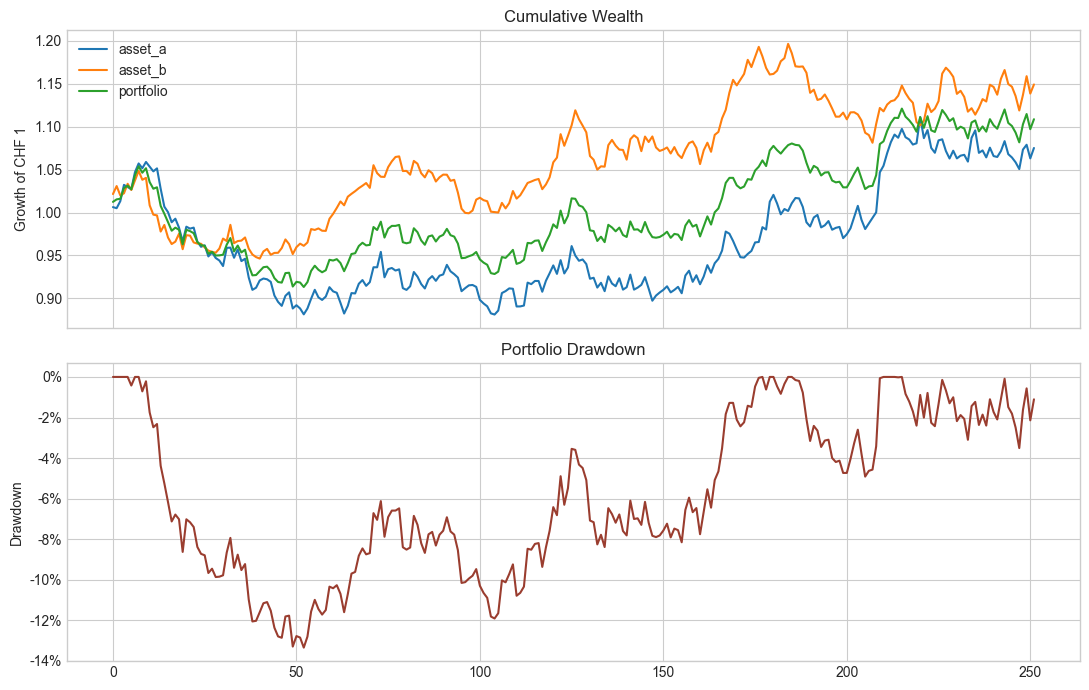

In [3]:
wealth = (1 + returns.assign(portfolio=portfolio_returns)).cumprod()
drawdown = wealth["portfolio"] / wealth["portfolio"].cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
wealth.plot(ax=axes[0])
axes[0].set_title("Cumulative Wealth")
axes[0].set_ylabel("Growth of CHF 1")

drawdown.plot(ax=axes[1], color="#9a3d2f")
axes[1].set_title("Portfolio Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()

## 5. Application

Risk and return concepts support asset allocation, portfolio construction, performance evaluation, and risk management. Diversification works when assets have imperfect correlation.

## 6. Reflection

- Return is reward; volatility is uncertainty around that reward.
- Correlation determines how much diversification helps.
- Sharpe ratio compares excess return with volatility.
- Drawdowns show the path risk investors actually experience.

Questions to answer after running the notebook:

1. Why can a lower-volatility portfolio be built from risky assets?
2. What does correlation measure that covariance does not standardize?
3. Why does drawdown matter even when average return is positive?
4. What does the Sharpe ratio ignore?